# Visualize quantum circuits, measurements, and states

### References
- https://quantum.cloud.ibm.com/docs/en/guides/visualize-circuits
- https://quantum.cloud.ibm.com/docs/en/guides/visualize-results
- https://quantum.cloud.ibm.com/docs/en/guides/plot-quantum-states
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.plot_bloch_multivector
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.plot_gate_map
- https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.visualization.plot_state_qsphere

## QSphere

The QSphere visualizes multi-qubit states. Instead of a single point, it places dots on a sphere — one dot per basis state that has non-zero amplitude. It is not mathematically exact like the Bloch sphere — we can't reconstruct the precise state just by looking at it

The latitude (north→south) corresponds to Hamming weight — how many qubits are |1⟩

Dot size encodes probability (|amplitude|²)

Dot colour encodes phase

|000⟩          ← 0 ones  →  North Pole
      
    |001⟩ |010⟩ |100⟩   ← 1 one   →  Upper ring

    |011⟩ |101⟩ |110⟩   ← 2 ones  →  Lower ring

         |111⟩          ← 3 ones  →  South Pole

show_state_labels=TruePrints |00⟩, |01⟩ etc. next to each dot

show_state_phases=FalseOptionally prints the phase value on each dot

use_degrees=FalseShow phase in radians (default) or degrees

North pole → |00...0⟩ (all zeros)

South pole → |11...1⟩ (all ones)

Rings in between → states with 1, 2, 3... ones in them

| Feature | Bloch Sphere | QSphere |
| :--- | :--- | :--- |
| **Qiskit Function** | `plot_bloch_multivector` | `plot_state_qsphere` |
| **Scope** | Single qubit per sphere | Multi-qubit system on one sphere |
| **Point Meaning** | The entire state of a single qubit | A single basis state (e.g., $\|011\rangle$) |
| **Organization** | X, Y, Z physical rotation axes | Latitude = **Hamming Weight** (count of 1s) |
| **Amplitude** | Polar angle $\theta$ | **Dot size** (Area $\propto$ Probability) |
| **Phase** | Azimuthal angle $\phi$ | **Dot color** (via color wheel) |
| **Entanglement** | Cannot show entanglement | **Shows entanglement** |
| **Input Type** | `Statevector`, `DensityMatrix` | `Statevector`, `DensityMatrix` |

Errors to know:

- If the input is not a valid N-qubit state → raises VisualizationError
- If the input ndarray has wrong dimensions → raises QiskitError
- If matplotlib is not installed → raises MissingOptionalLibraryError

### Statevector as input

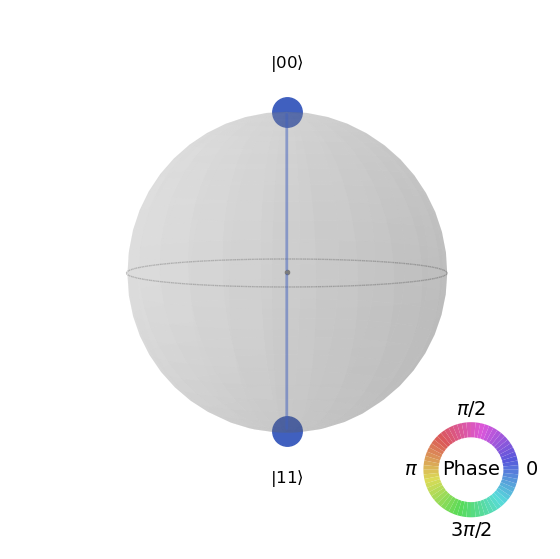

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
state = Statevector(qc)
plot_state_qsphere(state)

### Density Matrix as input

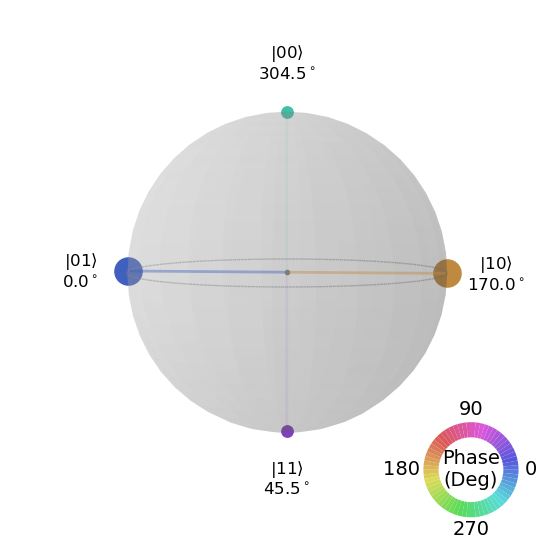

In [2]:
# You can show the phase of each state and use
# degrees instead of radians

from qiskit.quantum_info import DensityMatrix
import numpy as np
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_qsphere

qc = QuantumCircuit(2)
qc.h([0, 1])
qc.cz(0,1)
qc.ry(np.pi/3, 0)
qc.rx(np.pi/5, 1)
qc.z(1)

matrix = DensityMatrix(qc)
plot_state_qsphere(matrix, show_state_phases = True, use_degrees = True)

### Numpy array as input

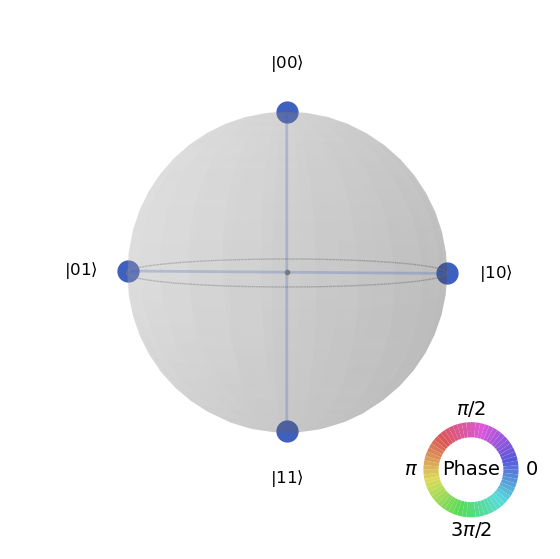

In [3]:
import numpy as np

# Statevector for |00> + |11> (unnormalized for clarity)
arr = np.array([1/np.sqrt(4), 1/np.sqrt(4), 1/np.sqrt(4), 1/np.sqrt(4)])
plot_state_qsphere(arr)

## Block Sphere

### Statevector as input

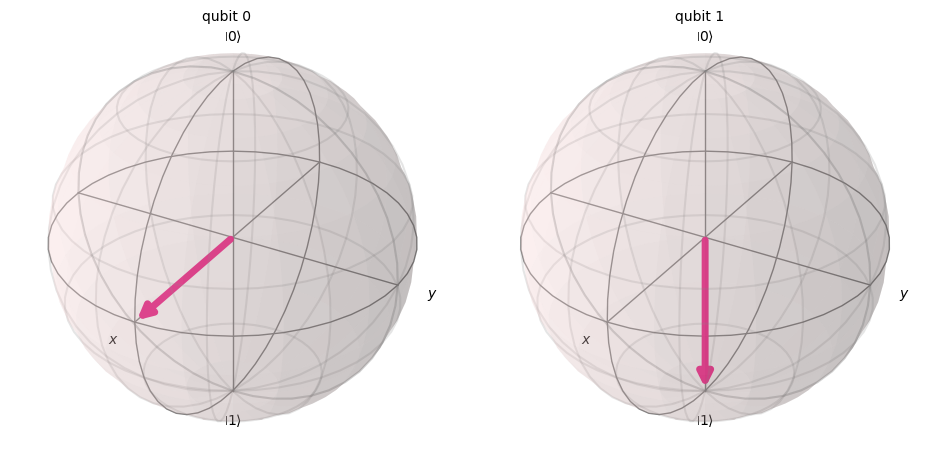

In [19]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)

state = Statevector(qc)
plot_bloch_multivector(state)

### Density Matrix as input

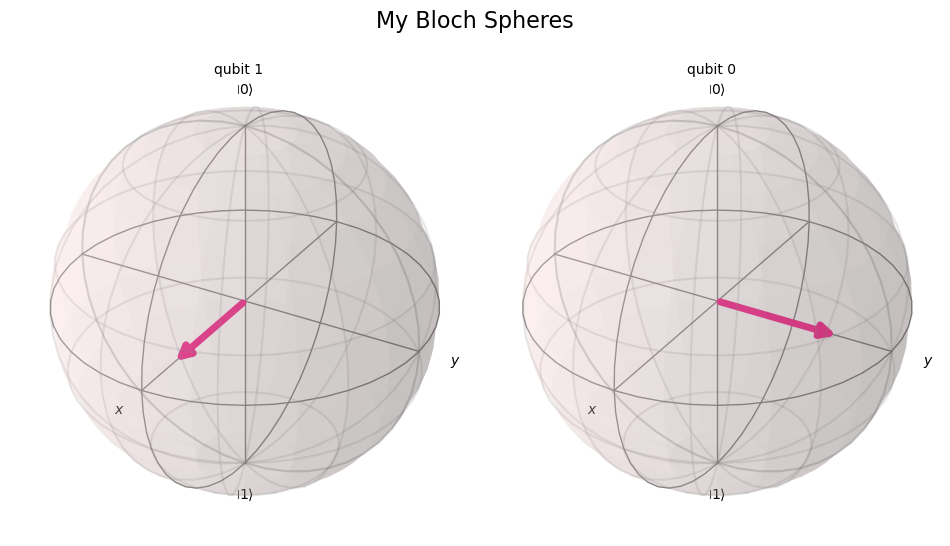

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)

# You can reverse the order of the qubits.

from qiskit.quantum_info import DensityMatrix

qc = QuantumCircuit(2)
qc.h([0, 1])
qc.t(1)
qc.s(0)
qc.cx(0,1)

matrix = DensityMatrix(qc)
plot_bloch_multivector(matrix, title='My Bloch Spheres', reverse_bits=True)

## plot_gate_map

plot_gate_map is a visualization tool in Qiskit used to display the physical connectivity (coupling map) of a quantum device.

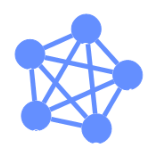

In [6]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_gate_map

backend = GenericBackendV2(num_qubits=5)

plot_gate_map(backend)

In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()

In [9]:
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=127)
backend.name

'ibm_fez'

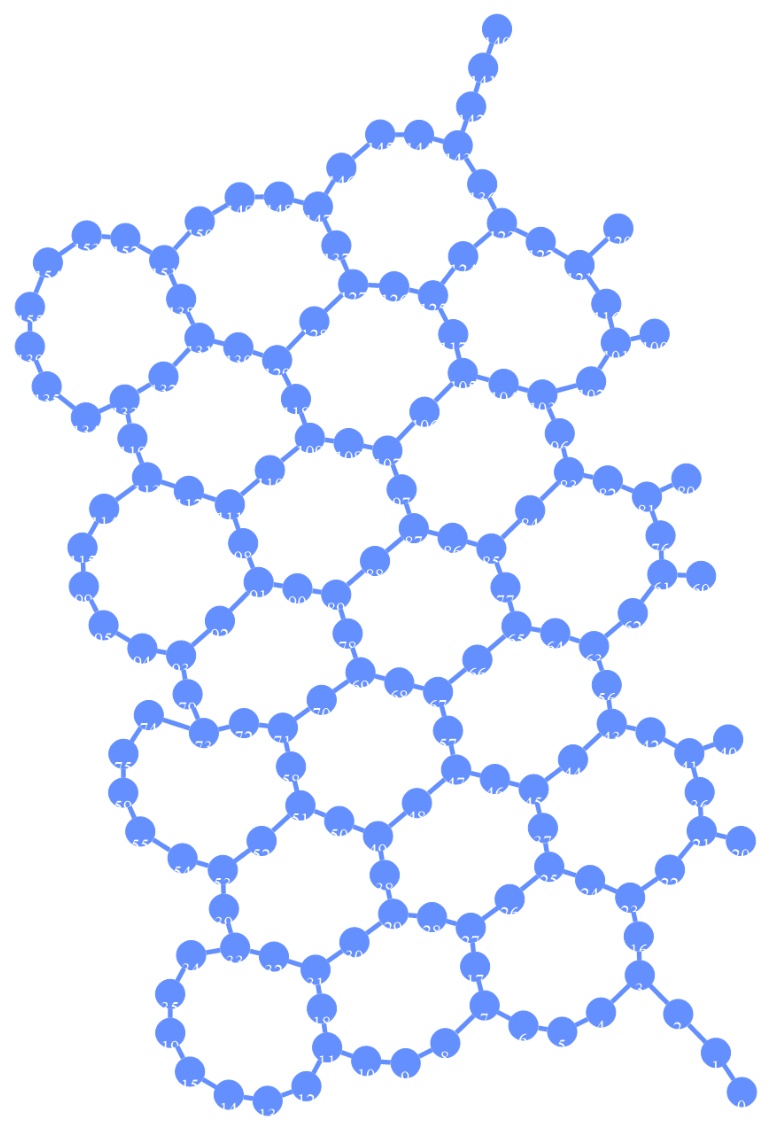

In [13]:
plot_gate_map(backend)

## Visualization

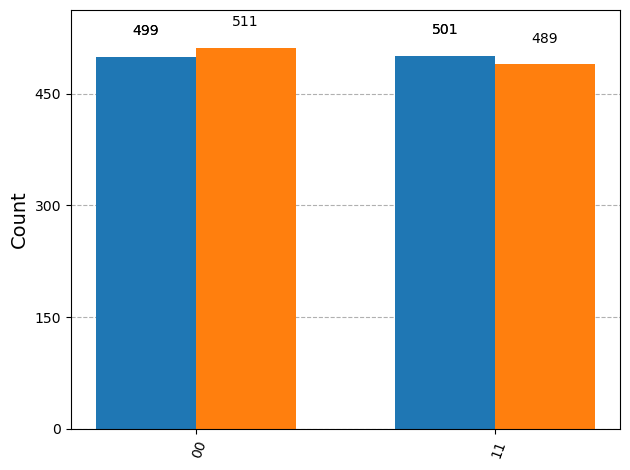

In [14]:
from qiskit.visualization import plot_histogram

counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}

data = [counts1, counts2]
plot_histogram(data)

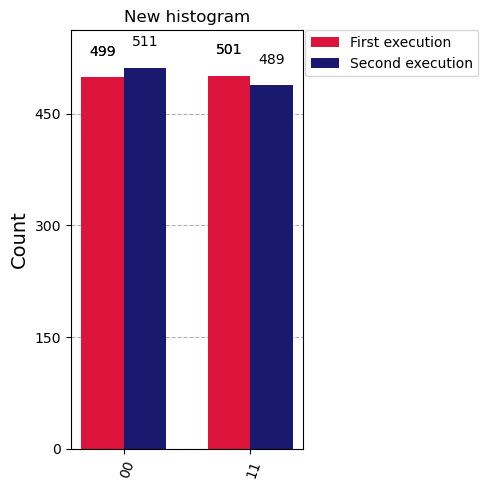

In [16]:
from qiskit.visualization import plot_histogram

counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}
data = [counts1, counts2]

legend = ['First execution', 'Second execution']
title = 'New histogram'
figsize = (5,5)
color=['crimson','midnightblue']
plot_histogram(data, legend=legend, title=title, figsize=figsize, color=color)

In [17]:
plot_histogram(data, filename='new_hist.png')

hist = plot_histogram(data)
hist.savefig('new_hist.png')

**plot_state_city is the standard way to visualize a Density Matrix ($\rho$). It is often called a "City" plot because it looks like a skyline of skyscrapers representing the state's values.**

A density matrix contains complex numbers ($a + bi$). Since a 3D bar chart can only show one value for height, Qiskit splits the visualization into two side-by-side graphs:

Left Plot (Real): Shows the real part of the numbers.

Right Plot (Imaginary): Shows the imaginary part (the phase components).

The grid at the bottom represents the indices of matrix, corresponding to the basis states $|0\rangle$ and $|1\rangle$.

The bars at positions (0,0) and (1,1) represent the populations of the state.

Index (0,0): The real bar has a height of 0.75. This means there is a 75% probability of measuring the state in $|0\rangle$.

Index (1,1): The real bar has a height of 0.25. This means there is a 25% probability of measuring the state in $|1\rangle$.

**Note: In the Imaginary plot, these diagonal bars are at 0 because probabilities must be real numbers.**

The bars at positions (0,1) and (1,0) represent the quantum interference or "coherence" between the states.

Index (0,1): defined this as 0.433j.

On the Real plot, the height is 0.

On the Imaginary plot, the height is +0.433.

Index (1,0): defined this as -0.433j.

On the Real plot, the height is 0.

On the Imaginary plot, the height is -0.433 (it goes "underground").

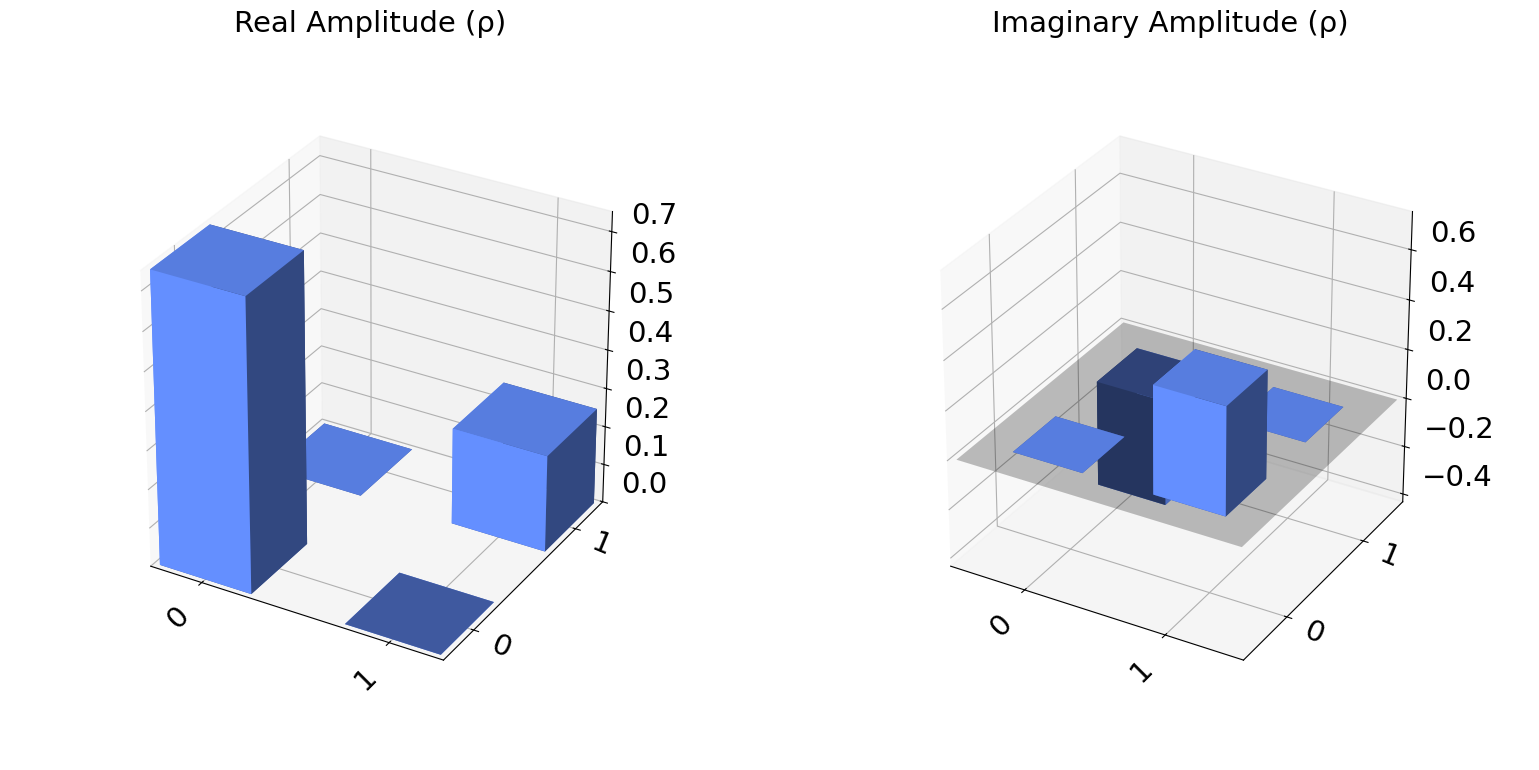

In [22]:
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_paulivec

state = [[ 0.75  , 0.433j],
         [-0.433j, 0.25  ]]
plot_state_city(state)

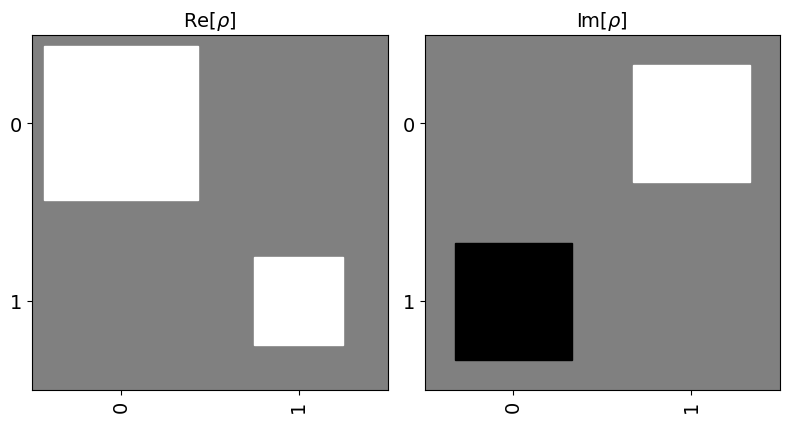

In [24]:
plot_state_hinton(state) # Similar to City, but uses square sizes; great for seeing which elements are dominant.

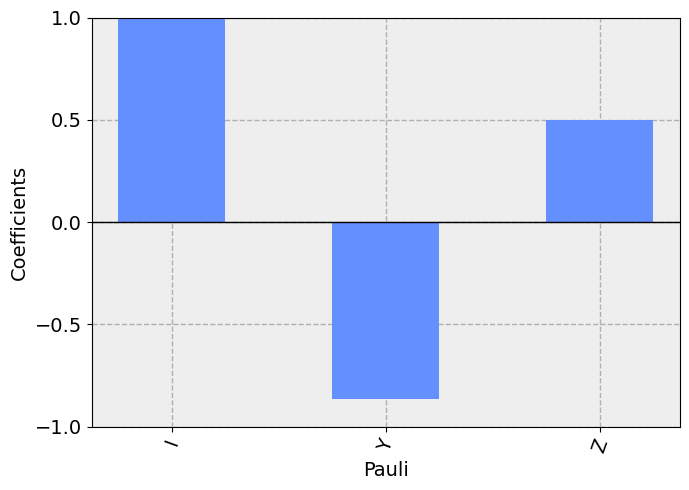

In [26]:
plot_state_paulivec(state) # Seeing the state's projection onto the X, Y, and Z axes.

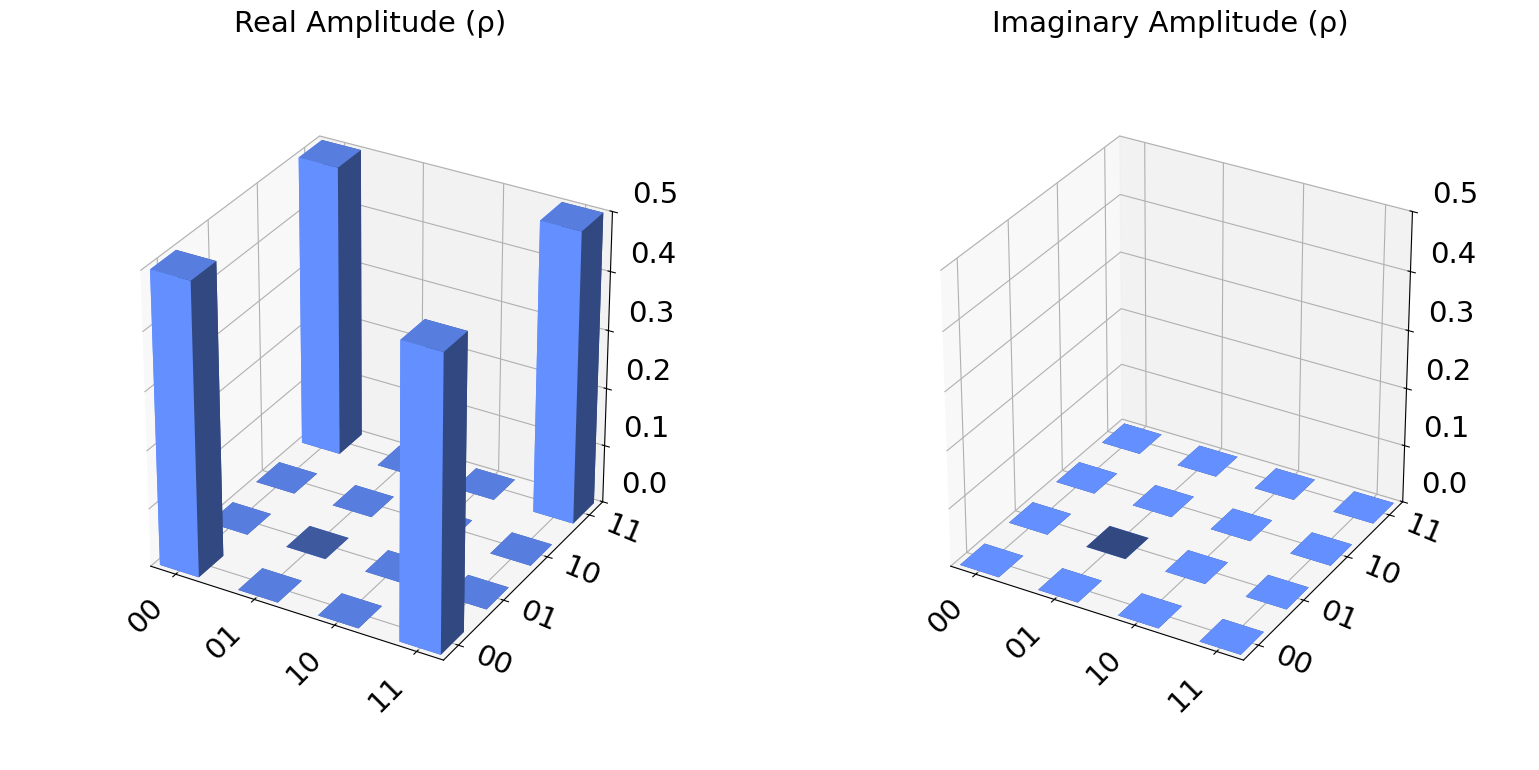

In [27]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

# plot using a Statevector
state = Statevector(qc)
plot_state_city(state)

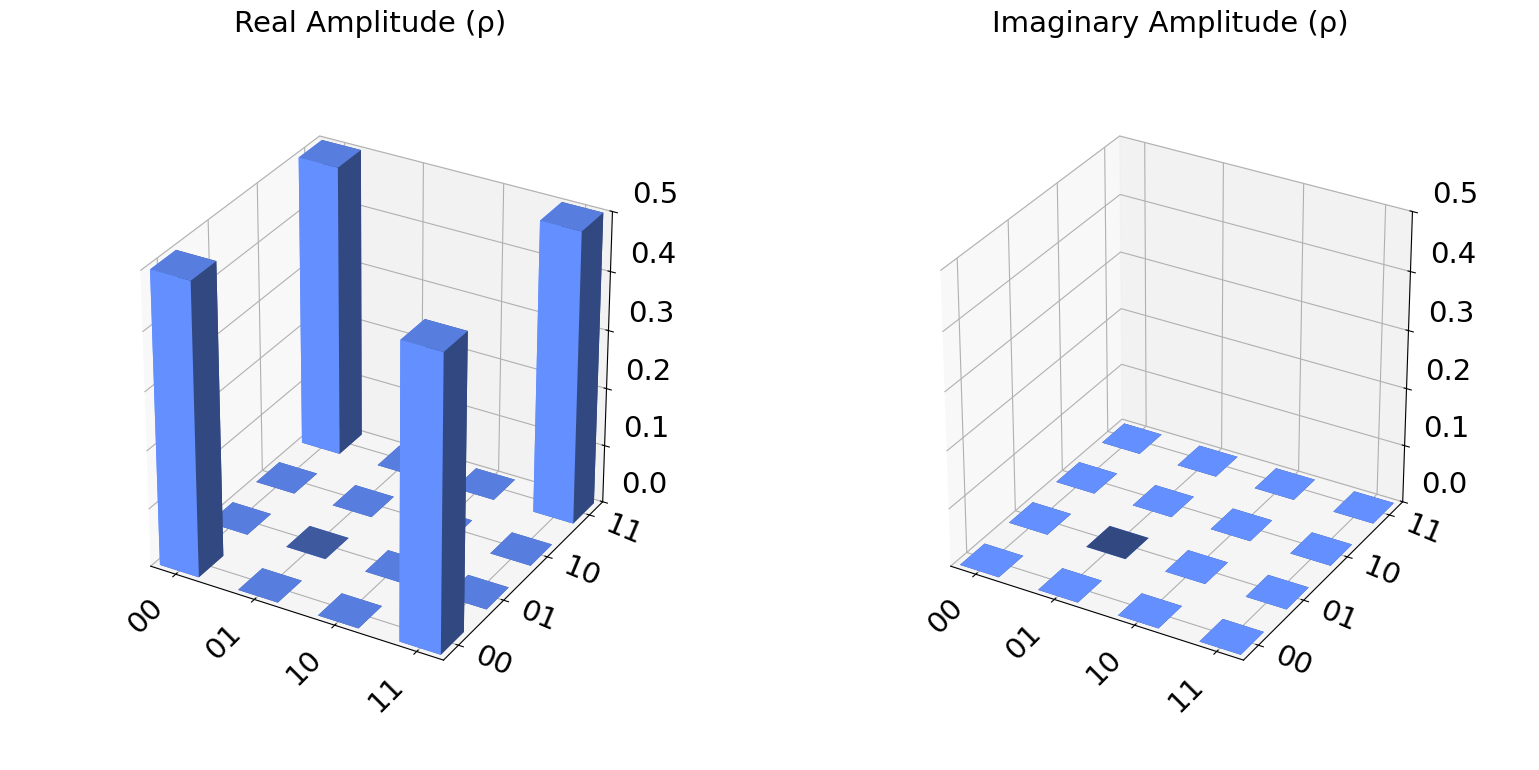

In [28]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

# plot using a DensityMatrix
state = DensityMatrix(qc)
plot_state_city(state)

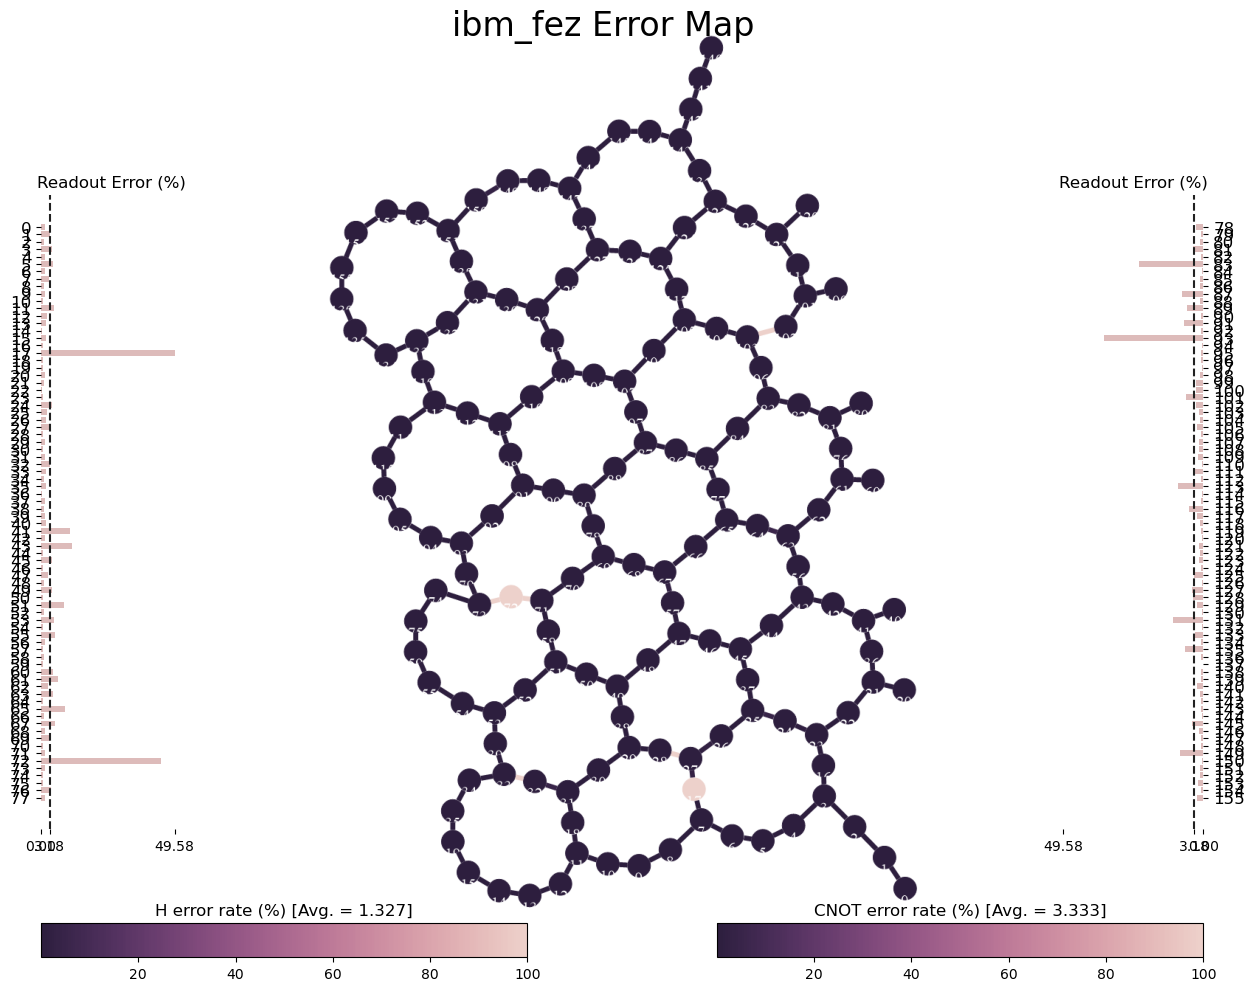

In [30]:
from qiskit.visualization import plot_error_map
plot_error_map(backend)

In [31]:
from qiskit import QuantumRegister, ClassicalRegister

# Draw a new circuit with barriers and more registers
q_a = QuantumRegister(3, name="a")
q_b = QuantumRegister(5, name="b")
c_a = ClassicalRegister(3)
c_b = ClassicalRegister(5)

circuit = QuantumCircuit(q_a, q_b, c_a, c_b)
circuit.x(q_a[1])
circuit.x(q_b[1])
circuit.x(q_b[2])
circuit.x(q_b[4])
circuit.barrier()
circuit.h(q_a)
circuit.barrier(q_a)
circuit.h(q_b)
circuit.cswap(q_b[0], q_b[1], q_b[2])
circuit.cswap(q_b[2], q_b[3], q_b[4])
circuit.cswap(q_b[3], q_b[4], q_b[0])
circuit.barrier(q_b)
circuit.measure(q_a, c_a)
circuit.measure(q_b, c_b);

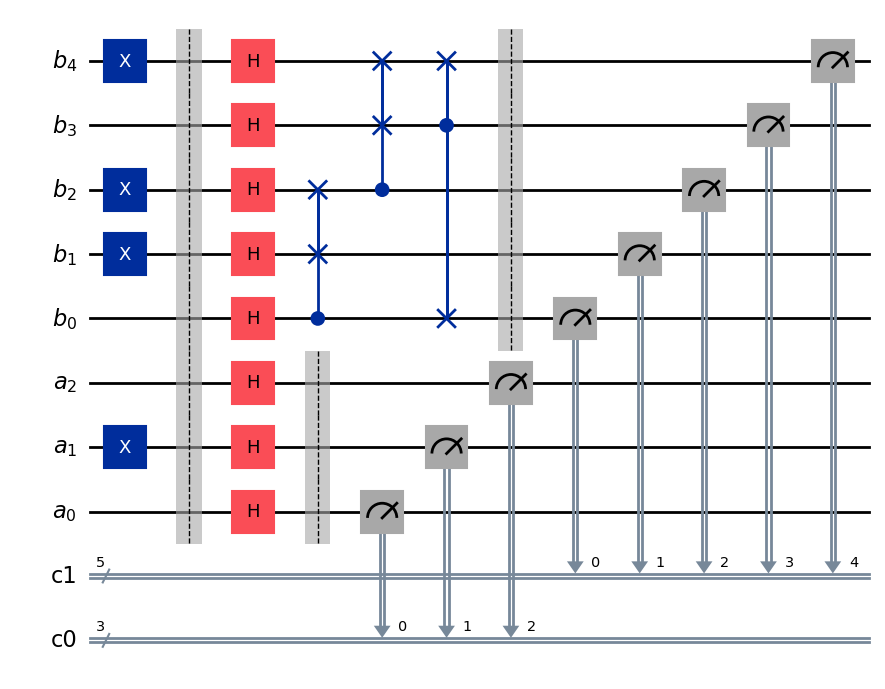

In [32]:
# Draw the circuit with reversed bit order
circuit.draw(output="mpl", reverse_bits=True)

In [35]:
# limit line length to 40 characters
circuit.draw(output="text", fold=40)

░ ┌───┐ ░    ┌─┐         »
 a_0: ──────░─┤ H ├─░────┤M├─────────»
      ┌───┐ ░ ├───┤ ░    └╥┘┌─┐      »
 a_1: ┤ X ├─░─┤ H ├─░─────╫─┤M├──────»
      └───┘ ░ ├───┤ ░     ║ └╥┘┌─┐   »
 a_2: ──────░─┤ H ├─░─────╫──╫─┤M├───»
            ░ ├───┤ ░     ║  ║ └╥┘   »
 b_0: ──────░─┤ H ├─■─────╫──╫──╫──X─»
      ┌───┐ ░ ├───┤ │     ║  ║  ║  │ »
 b_1: ┤ X ├─░─┤ H ├─X─────╫──╫──╫──┼─»
      ├───┤ ░ ├───┤ │     ║  ║  ║  │ »
 b_2: ┤ X ├─░─┤ H ├─X──■──╫──╫──╫──┼─»
      └───┘ ░ ├───┤    │  ║  ║  ║  │ »
 b_3: ──────░─┤ H ├────X──╫──╫──╫──■─»
      ┌───┐ ░ ├───┤    │  ║  ║  ║  │ »
 b_4: ┤ X ├─░─┤ H ├────X──╫──╫──╫──X─»
      └───┘ ░ └───┘       ║  ║  ║    »
c0: 3/════════════════════╩══╩══╩════»
                          0  1  2    »
c1: 5/═══════════════════════════════»
                                     »
«                        
« a_0: ──────────────────
«                        
« a_1: ──────────────────
«                        
« a_2: ──────────────────
«       ░ ┌─┐            
« b_0: ─░─┤M├────────────
«       ░ └╥┘┌─┐         
« b_1: ─░──╫─┤M├─────────
«       ░  ║ └╥┘┌─┐      
« b_2: ─░──╫──╫─┤M├──────
«       ░  ║  ║ └╥┘┌─┐   
« b_3: ─░──╫──╫──╫─┤M├───
«       ░  ║  ║  ║ └╥┘┌─┐
« b_4: ─░──╫──╫──╫──╫─┤M├
«       ░  ║  ║  ║  ║ └╥┘
«c0: 3/════╬══╬══╬══╬══╬═
«          ║  ║  ║  ║  ║ 
«c1: 5/════╩══╩══╩══╩══╩═
«          0  1  2  3  4

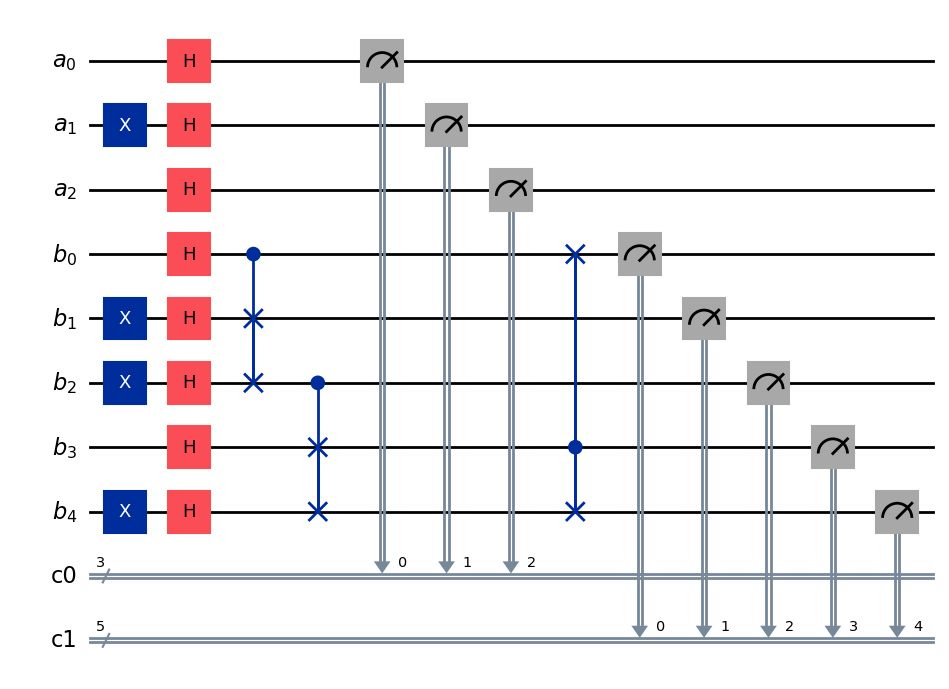

In [37]:
from qiskit.visualization import circuit_drawer
# circuit_drawer() function, which is part of the public stable interface from qiskit.visualization
# The function behaves identically to the circuit.draw() method, except that it takes in a circuit object as a required argument.
circuit_drawer(circuit, output="mpl", plot_barriers=False)